In [8]:
!git clone https://github.com/jonjon-levi/m146-final-project.git

Cloning into 'm146-final-project'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 3), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 294.09 KiB | 1.22 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [9]:
%cd m146-final-project

/content/m146-final-project


In [10]:
!pip install evaluate transformers datasets sentence-transformers scikit-learn matplotlib peft accelerate trl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.7 MB/s eta 0:00:00


In [11]:
from datasets import load_dataset
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer
import evaluate

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
    AutoModelForCausalLM
)

import torch

##Part A.1 (a)

In [12]:
ds = load_dataset("google-research-datasets/paws", "labeled_final")

train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

print("Split sizes:")
print(f"Train:      {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test:       {len(test_df)}")

train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.79k [00:00<?, ?B/s]

labeled_final/train-00000-of-00001.parqu(…):   0%|          | 0.00/8.43M [00:00<?, ?B/s]

labeled_final/test-00000-of-00001.parque(…):   0%|          | 0.00/1.24M [00:00<?, ?B/s]

labeled_final/validation-00000-of-00001.(…):   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49401 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Split sizes:
Train:      49401
Validation: 8000
Test:       8000


,id,sentence1,sentence2,label
0,1,"In Paris , in October 1560 , he secretly met t...","In October 1560 , he secretly met with the Eng...",0
1,2,The NBA season of 1975 -- 76 was the 30th seas...,The 1975 -- 76 season of the National Basketba...,1
2,3,"There are also specific discussions , public p...","There are also public discussions , profile sp...",0
3,4,When comparable rates of flow can be maintaine...,The results are high when comparable flow rate...,1
4,5,It is the seat of Zerendi District in Akmola R...,It is the seat of the district of Zerendi in A...,1


In [6]:
def show_label_distribution(df, split_name):
    counts = df["label"].value_counts().sort_index()
    proportions = df["label"].value_counts(normalize=True).sort_index()

    print(f"\n{split_name} label distribution:")

    for label in counts.index:
        print(
            f"Label {label}: "
            f"{counts[label]} examples "
            f"({proportions[label] * 100:.2f}%)"
        )

show_label_distribution(train_df, "Train")
show_label_distribution(val_df, "Validation")
show_label_distribution(test_df, "Test")


Train label distribution:
Label 0: 27572 examples (55.81%)
Label 1: 21829 examples (44.19%)

Validation label distribution:
Label 0: 4461 examples (55.76%)
Label 1: 3539 examples (44.24%)

Test label distribution:
Label 0: 4464 examples (55.80%)
Label 1: 3536 examples (44.20%)


##Part A.1 (b)



In [7]:
def tokenize(text):
    return set(re.findall(r"\b\w+\b", text.lower()))

def jaccard_similarity(s1, s2):
    tokens1 = tokenize(s1)
    tokens2 = tokenize(s2)
    intersection = len(tokens1 & tokens2)
    union = len(tokens1 | tokens2)

    if union != 0:
      return (intersection / union)
    else:
      return 0

test_df["overlap_score"] = test_df.apply(
    lambda row: jaccard_similarity(row["sentence1"], row["sentence2"]),
    axis=1
)

high_overlap_label0 = (
    test_df[test_df["label"] == 0]
    .sort_values("overlap_score", ascending=False)
    .head(3)
)

high_overlap_label1 = (
    test_df[test_df["label"] == 1]
    .sort_values("overlap_score", ascending=False)
    .head(3)
)

print("High-overlap examples with label 0:\n")

for i, row in high_overlap_label0.iterrows():
    print(f"Overlap Score: {row['overlap_score']:.3f}")
    print(f"Sentence 1: {row['sentence1']}")
    print(f"Sentence 2: {row['sentence2']}")
    print("-----------------------------------\n")

print("\nHigh-overlap examples with label 1:\n")

for i, row in high_overlap_label1.iterrows():
    print(f"Overlap Score: {row['overlap_score']:.3f}")
    print(f"Sentence 1: {row['sentence1']}")
    print(f"Sentence 2: {row['sentence2']}")
    print("-----------------------------------\n")

High-overlap examples with label 0:

Overlap Score: 1.000
Sentence 1: Sullivan returned to politics in 1892 and defeated Denny .
Sentence 2: Denny returned to politics in 1892 and defeated Sullivan .
-----------------------------------

Overlap Score: 1.000
Sentence 1: To the north is Stewartstown , to the east is Columbia and to the south is Dixville .
Sentence 2: To the north is Stewartstown , Dixville to the east and Columbia to the south .
-----------------------------------

Overlap Score: 1.000
Sentence 1: A unique feature of the human metate is the lack of ceremonial figures .
Sentence 2: A unique feature of ceremonial metate is the lack of human figures .
-----------------------------------


High-overlap examples with label 1:

Overlap Score: 1.000
Sentence 1: According to the United States Census Bureau , Ardmore has a total area of , of which is land and , or 3.67 % , is water .
Sentence 2: According to the United States Census Bureau , Ardmore is a total area of which land 

The high overlap nonparaphrased examples are difficult because the two sentences often contain nearly identical words, but they differ in meaning because of their ordering. So even if two sentences have a high similarity score in terms of words, their meaning could be completely different.

## Part A.1(c)

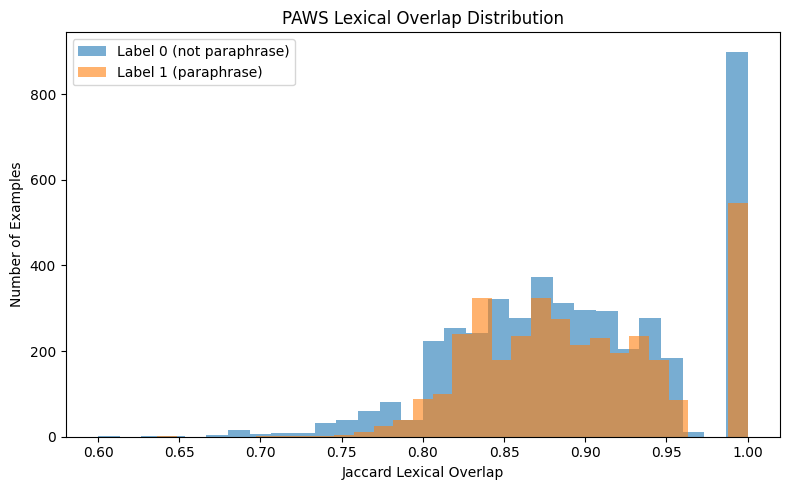

In [8]:
label0_scores = test_df[test_df["label"] == 0]["overlap_score"]
label1_scores = test_df[test_df["label"] == 1]["overlap_score"]

plt.figure(figsize=(8, 5))

plt.hist(
    label0_scores,
    bins=30,
    alpha=0.6,
    label="Label 0 (not paraphrase)"
)

plt.hist(
    label1_scores,
    bins=30,
    alpha=0.6,
    label="Label 1 (paraphrase)"
)

plt.xlabel("Jaccard Lexical Overlap")
plt.ylabel("Number of Examples")
plt.title("PAWS Lexical Overlap Distribution")
plt.legend()
plt.tight_layout()
plt.show()

The above graph shows that clearly there is an overlap between the two distributions. It is also clear to see that even though paraphrases have high lexical overlap, so do non-paraphrase examples which is enough evidence to understand that lexical overlap alone is not enough to solve PAWS.



## Part A.1(d)

I expect that the cross-encoder model will achiece a higher accuracy than the bi-encoder model. Even though a bi-encoder will be more computationally efficient as sentence embeddings can be cached and reused, it may not work as well on this task as seen above: many sentence pairs conatin nearly identitcal words but differ in meaning. Whereas the cross-encoder is slower, but allows attention mechanisms to directly compare tokens and phrases across the two sentences at each layer. This will probably allow the cross-encoder to understand the semantic differences and achieve a higher accuracy.

## Part A.2(a)

In [9]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
bi_encoder = SentenceTransformer(model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
train_s1_embeddings = bi_encoder.encode(
    train_df["sentence1"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

train_s2_embeddings = bi_encoder.encode(
    train_df["sentence2"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

val_s1_embeddings = bi_encoder.encode(
    val_df["sentence1"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

val_s2_embeddings = bi_encoder.encode(
    val_df["sentence2"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

test_s1_embeddings = bi_encoder.encode(
    test_df["sentence1"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

test_s2_embeddings = bi_encoder.encode(
    test_df["sentence2"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

Batches:   0%|          | 0/772 [00:00<?, ?it/s]

Batches:   0%|          | 0/772 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

In [11]:
def build_features(u, v):
    return np.hstack([
        u,
        v,
        np.abs(u - v),
        u * v
    ])

X_train = build_features(train_s1_embeddings, train_s2_embeddings)
X_val = build_features(val_s1_embeddings, val_s2_embeddings)
X_test = build_features(test_s1_embeddings, test_s2_embeddings)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Test feature shape:", X_test.shape)

Training feature shape: (49401, 1536)
Validation feature shape: (8000, 1536)
Test feature shape: (8000, 1536)


In [12]:
C_values = [0.01, 0.1, 1, 10]

best_model = None
best_C = None
best_val_accuracy = 0

for C in C_values:

    clf = LogisticRegression(C=C, max_iter=1000)
    clf.fit(X_train, y_train)
    val_preds = clf.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_preds)

    print(f"C = {C}")
    print(f"Validation Accuracy = {val_accuracy:.4f}\n")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_C = C
        best_model = clf

print("Best C:", best_C)
print("Best Validation Accuracy:", round(best_val_accuracy, 4))

C = 0.01
Validation Accuracy = 0.5984

C = 0.1
Validation Accuracy = 0.6071

C = 1
Validation Accuracy = 0.6224

C = 10
Validation Accuracy = 0.6212

Best C: 1
Best Validation Accuracy: 0.6224


Test Accuracy: 0.6182
Test F1 Score: 0.5268


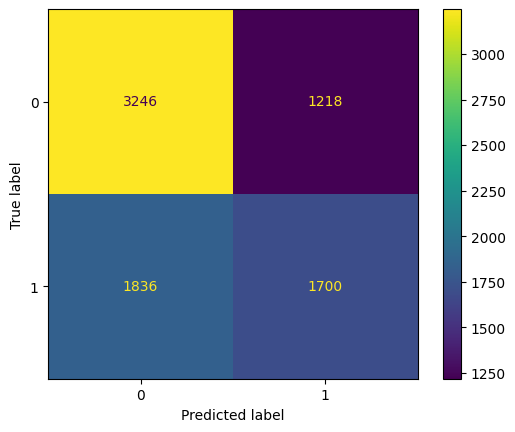

In [14]:
test_preds = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Here we constructed the feature pair as such:
$$ [u,\ v,\ |u-v|,\ u \odot v] $$

Where:
- u and v are feature embeddings
- u-v is the semantic differences
- u dotted with v captures the elementwise similiarity  

This was what we chose because it allowes for the understanding of the independtent semantic information from each of the sentences, as well as a distance based comparison the information and the deature interaction information.

After that we trained a Logistic Regression classifier on these features and tuned the regularization parameter, C, and found that the best validation performance was achieved with C = 1. This was used for final evaluation on the test split.

## Part A.2(b)

In [19]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
cross_encoder = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
train_dataset = Dataset.from_pandas(train_df[["sentence1", "sentence2", "label"]])
val_dataset = Dataset.from_pandas(val_df[["sentence1", "sentence2", "label"]])
test_dataset = Dataset.from_pandas(test_df[["sentence1", "sentence2", "label"]])

def tokenize_function(examples):
    return tokenizer(
        examples["sentence1"],
        examples["sentence2"],
        truncation=True,
        padding="max_length",
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["sentence1", "sentence2"])
val_dataset = val_dataset.remove_columns(["sentence1", "sentence2"])
test_dataset = test_dataset.remove_columns(["sentence1", "sentence2"])

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

Map:   0%|          | 0/49401 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [31]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels)

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

In [32]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [33]:
training_args = TrainingArguments(
    output_dir="cross_encoder_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

trainer = Trainer(
    model=cross_encoder,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [34]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.276943,0.336821,0.865125,0.856535


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3088, training_loss=0.4193021701407556, metrics={'train_runtime': 2552.6782, 'train_samples_per_second': 19.353, 'train_steps_per_second': 1.21, 'total_flos': 6544021961005056.0, 'train_loss': 0.4193021701407556, 'epoch': 1.0})

In [37]:
training_args = TrainingArguments(
    output_dir="cross_encoder_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=5e-5, #second iteration with different learning rate

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

trainer = Trainer(
    model=cross_encoder,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [38]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.205914,0.332452,0.884875,0.877216


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3088, training_loss=0.2545080975547356, metrics={'train_runtime': 2549.9361, 'train_samples_per_second': 19.373, 'train_steps_per_second': 1.211, 'total_flos': 6544021961005056.0, 'train_loss': 0.2545080975547356, 'epoch': 1.0})

The learning rate: $5 \times 10^{-5}$ achieved higher validation accuracy than $2 \times 10^{-5}$, so we selected it as the final model for test evaluation.


Test Accuracy: 0.8792
Test F1 Score: 0.8698


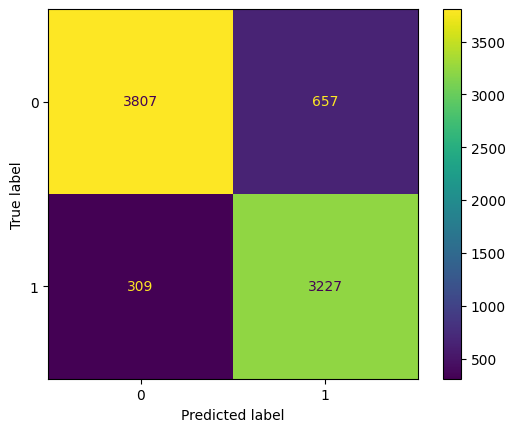

In [39]:
test_results = trainer.predict(test_dataset)

test_logits = test_results.predictions
test_preds = np.argmax(test_logits, axis=1)

test_accuracy = accuracy_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

## Part A.2(c)

In [40]:
bi_test_preds = best_model.predict(X_test)

cross_test_results = trainer.predict(test_dataset)
cross_test_preds = np.argmax(cross_test_results.predictions, axis=1)

disagreement_indices = np.where((bi_test_preds != y_test) & (cross_test_preds == y_test))[0]
print("Number of disagreement examples:", len(disagreement_indices))

Number of disagreement examples: 2632


In [41]:
num_examples = 5

for idx in disagreement_indices[:num_examples]:
    print("-------------------------\n")

    print("True Label:", y_test[idx])
    print("Bi-encoder Prediction:", bi_test_preds[idx])
    print("Cross-encoder Prediction:", cross_test_preds[idx])

    print("\nSentence 1:")
    print(test_df.iloc[idx]["sentence1"])

    print("\nSentence 2:")
    print(test_df.iloc[idx]["sentence2"])

    print("\n")

-------------------------

True Label: 0
Bi-encoder Prediction: 1
Cross-encoder Prediction: 0

Sentence 1:
Steiner argued that , in the right circumstances , the spiritual world can be explored through direct experience by practicing ethical and cognitive forms of rigorous self-discipline .

Sentence 2:
Steiner held that the spiritual world can be researched in the right circumstances through direct experience , by persons practicing rigorous forms of ethical and cognitive self-discipline .


-------------------------

True Label: 0
Bi-encoder Prediction: 1
Cross-encoder Prediction: 0

Sentence 1:
Luciano Williames Dias ( born July 25 , 1970 ) is a Brazilian football coach and former player .

Sentence 2:
Luciano Williames Dias ( born 25 July 1970 ) is a former football coach and Brazilian player .


-------------------------

True Label: 1
Bi-encoder Prediction: 0
Cross-encoder Prediction: 1

Sentence 1:
His father emigrated to Missouri in 1868 , but returned when his wife became ill 

It is clear to see that the cross-encoder was correct more often on these examples, which matches the quantitative results (the cross-encoder achieved a much higher accuracy and F1 score than the bi-encoder).  
A common pattern that we noticde is that in these examples many sentence pairs contained swapped subjects and objects, or other subtle changes that altered the meaning of the sentence. And as we predicted in our hypothesis the cross-encoder will be a much better model in regards to understanding sentences/paraphrases.

## Part A.2(d)

In [43]:
comparison_results = pd.DataFrame({
    "Model": [
        "Bi-encoder",
        "Cross-encoder"
    ],

    "Test Accuracy": [
        0.6182,
        0.8792
    ],

    "Test F1": [
        0.5268,
        0.8698
    ],

    "Confusion Matrix Summary": [
        "TN=3246, FP=1218, FN=1836, TP=1700",
        "TN=3807, FP=657, FN=309, TP=3227"
    ],

    "Approx. Inference Time / 1000 Pairs": [
        "~1-2 seconds",
        "~40-60 seconds"
    ]
})

comparison_results

,Model,Test Accuracy,Test F1,Confusion Matrix Summary,Approx. Inference Time / 1000 Pairs
0,Bi-encoder,0.6182,0.5268,"TN=3246, FP=1218, FN=1836, TP=1700",~1-2 seconds
1,Cross-encoder,0.8792,0.8698,"TN=3807, FP=657, FN=309, TP=3227",~40-60 seconds


It is clear to see through the above table, as well as the previous experiements that the Cross-encoder outperformed the bi-encoder on the PAWS task.   
Nevertheless, the bi-encoder is much more efficient since sentence embeddings can be precomputed and reused across comparisons. That being said, because the bi-ecoder encodes sentences independently, it struggles on PAWS examples where meaning depend on swapped entities, word order, etc.
Therefore, if accuracy is the primary objective, the cross-encoder is definitely the better choice. And if fast retreival or repeated comparisons are more important, then I would reccomend the bi-encoder just because sentence embeddings can be reused efficiently.

## Part A.3(a)

In [13]:
np.random.seed(42)

test_label_0 = test_df[test_df["label"] == 0]
test_label_1 = test_df[test_df["label"] == 1]

subset_label_0 = test_label_0.sample(n=100, random_state=42)
subset_label_1 = test_label_1.sample(n=100, random_state=42)

prompt_subset_df = pd.concat([
    subset_label_0,
    subset_label_1
]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Subset size:", len(prompt_subset_df))

print("\nLabel distribution:")
print(prompt_subset_df["label"].value_counts())

Subset size: 200

Label distribution:
label
0    100
1    100
Name: count, dtype: int64


## Part A.3(b)

In [14]:
INSTRUCT_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

PAWS_PROMPT_TEMPLATE = """
You are a paraphrase classification system.

Determine whether the following two sentences are paraphrases.

Only output one word:
paraphrase
or
not_paraphrase

Sentence 1:
{sentence1}

Sentence 2:
{sentence2}

Answer:
""".strip()


def load_instruct_model(model_name=INSTRUCT_MODEL):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto"
    )
    model.eval()
    return model, tokenizer


def chat_text(tokenizer, messages):
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def make_paws_prompt(sentence1, sentence2):
    return PAWS_PROMPT_TEMPLATE.format(sentence1=sentence1, sentence2=sentence2)


def parse_paws_output(text):
    cleaned = (text.strip().lower().replace("-", "_").replace(" ", "_"))
    if "not_paraphrase" in cleaned:
        return 0
    if re.search(r"\bparaphrase\b", cleaned):
        return 1
    return -1


def balanced_subset(df, n_per_class=100, seed=42):
    rng = np.random.default_rng(seed)
    label_0 = df[df["label"] == 0].sample(n=n_per_class, random_state=seed)
    label_1 = df[df["label"] == 1].sample(n=n_per_class, random_state=seed)
    subset = (pd.concat([label_0, label_1]).sample(frac=1, random_state=seed).reset_index(drop=True))
    return subset


def generate_texts(model, tokenizer, prompts, max_new_tokens=5, batch_size=2):
    outputs = []
    for start in range(0, len(prompts), batch_size):
        batch = prompts[start:start + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            generated = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch)):
            decoded = tokenizer.decode( generated[i][prompt_len:], skip_special_tokens=True).strip()
            outputs.append(decoded)
    return outputs


def evaluate_prompted_paws(model, tokenizer, subset_df):
    prompts = []
    for _, row in subset_df.iterrows():
        messages = [{"role": "user", "content": make_paws_prompt(row["sentence1"],row["sentence2"])}]
        prompts.append(chat_text(tokenizer, messages))
    raw_outputs = generate_texts(model, tokenizer, prompts, batch_size=8)
    preds = np.array([parse_paws_output(x) for x in raw_outputs])
    y_true = subset_df["label"].values
    accuracy = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    cm = confusion_matrix(y_true, preds)
    return accuracy, f1, cm, preds, raw_outputs

In [15]:
model, tokenizer = load_instruct_model()

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [16]:
prompt_subset_df = balanced_subset(test_df, n_per_class=100)

In [11]:
zero_shot_accuracy, zero_shot_f1, cm, preds, raw_outputs = evaluate_prompted_paws(model, tokenizer, prompt_subset_df)

Zero-shot Accuracy: 0.6500
Zero-shot F1 Score: 0.7368


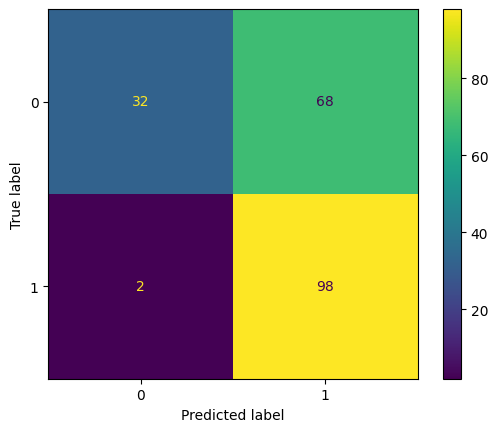

In [12]:
print(f"Zero-shot Accuracy: {zero_shot_accuracy:.4f}")
print(f"Zero-shot F1 Score: {zero_shot_f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Part A.3(c)

In [13]:
few_shot_examples = []
train_paraphrase = train_df[train_df["label"] == 1].sample(n=3, random_state=42)
train_not_paraphrase = train_df[train_df["label"] == 0].sample(n=3, random_state=42)
few_shot_df = pd.concat([train_paraphrase, train_not_paraphrase]).sample(frac=1, random_state=42)
for _, row in few_shot_df.iterrows():
    few_shot_examples.append({
        "sentence1": row["sentence1"],
        "sentence2": row["sentence2"],
        "label": row["label"]
    })

In [2]:
def evaluate_prompted_paws(model, tokenizer, subset_df, few_shot_examples=None):
    prompts = []
    for _, row in subset_df.iterrows():
        messages = []
        if few_shot_examples:
            for fs in few_shot_examples:
                messages = [{"role": "user", "content": make_paws_prompt(row["sentence1"],row["sentence2"])}]
                messages.append({"role": "assistant", "content":"paraphrase" if fs["label"] == 1 else "not_paraphrase"})

        messages.append({"role": "user", "content": make_paws_prompt(row["sentence1"], row["sentence2"])})
        prompts.append(chat_text(tokenizer, messages))

    raw_outputs = generate_texts(model, tokenizer, prompts, batch_size=8)
    preds = np.array([parse_paws_output(x) for x in raw_outputs])
    y_true = subset_df["label"].values
    accuracy = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    cm = confusion_matrix(y_true, preds)
    return accuracy, f1, cm, preds, raw_outputs

In [15]:
few_shot_accuracy, few_shot_f1, cm_fs, preds_fs, raw_outputs_fs = evaluate_prompted_paws(model, tokenizer, prompt_subset_df, few_shot_examples=few_shot_examples)

Few-shot Accuracy: 0.7150
Few-shot F1 Score: 0.6275


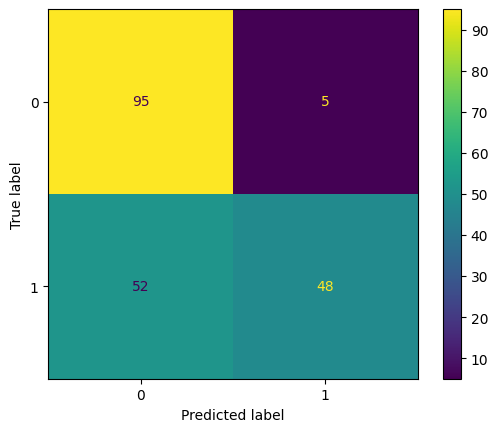

In [16]:
print(f"Few-shot Accuracy: {few_shot_accuracy:.4f}")
print(f"Few-shot F1 Score: {few_shot_f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_fs)
disp.plot()
plt.show()

## Part A.3(d)

Prompt-based classification model: Qwen/Qwen2.5-1.5B-Instruct  

#### Results:
Few-shot prompting: Accuracy = 0.7150, F1 Score = 0.6275  
Zero-shot prompting: Accuracy = 0.6500, F1 Score = 0.7368  
Cross-encoder: Accuracy = 0.8792, F1 Score = 0.8698

       
#### Analysis:
It is clear to see that the cross-encoder has the best performance with the highest accuracy as well as teh highest F1 Score. This was expected since it was trained on PAWS and learns sentence-pair decision boundaries. The instruction model was only prompted, which makes sense why it did not get a good accuracy in comparison. The zero-shot model produced many false positives. Furthermore, the few-shot model changed the behaviour so that there were less of these false positives but more false negatives. This implies that the prompt based models are sensitive to examples and wording.
    
Finally, in regards of runtime the cross-encoder was the fastest and the instruction models were much slower even though prompting requires no training. I would not use prompting if accuracy is most important but for singular cases it could be useful as a baseline

## Part A.3(e)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Alternative Prompt Accuracy: 0.7700
Alternative Prompt F1 Score: 0.8000


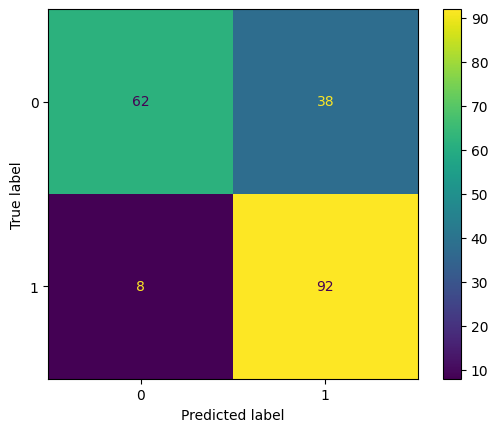

In [17]:
PAWS_PROMPT_TEMPLATE = """
You are a semantic similarity classifier.

Determine whether the following two sentences express the same meaning.

Only output one word:
paraphrase
or
not_paraphrase

Sentence 1:
{sentence1}

Sentence 2:
{sentence2}

Answer:
""".strip()

alt_accuracy, alt_f1, alt_cm, alt_preds, alt_raw_outputs = evaluate_prompted_paws(model, tokenizer, prompt_subset_df)

print(f"Alternative Prompt Accuracy: {alt_accuracy:.4f}")
print(f"Alternative Prompt F1 Score: {alt_f1:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=alt_cm)
disp.plot()
plt.show()

As we can see above, the results to change significantly.  
Original Zero-Prompt Results: Accuracy = 0.6500, F1 = 0.7368  
Alternative Prompt Results: Accuracy = 0.7700, F1 = 0.8000  

This implies that these instruction-tuned language models are relatively sensitive in regards to the prompt when used as classifiers. This is because we see a great difference in results where merely changing the instruction prompt slightly. Finally, this shows that compared to supervised fine-tuning, prompt based classifiers can be less reproducible because wording differences causes change in the balance of false positives and false negatives.